# Данные и EDA

Содержание:
- Описание данных;
- Загрузка;
- Проверки качества данных;
- Сборка единого датасета;
- Первичный анализ: распределения, выбросы, пропуски, базовые визуализации;
- Разделение на train/val/test выборки;
- Обогащение;
- Артефакты;
- Заключение.

## Описание данных

Используемый датасет - ml-latest-small

Этот набор данных (ml-latest-small) описывает 5-звездочные рейтинги и текстовые теги, добавленные пользователями MovieLens, сервиса рекомендаций фильмов. Он содержит 100 836 оценок и 3683 тега для 9742 фильмов. Эти данные были созданы 610 пользователями в период с 29 марта 1996 года по 24 сентября 2018 года. Этот набор данных был создан 26 сентября 2018 года.

F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. ACM Transactions on Interactive Intelligent Systems (TiiS) 5, 4: 19:1–19:19. https://doi.org/10.1145/2827872

## Загрузка

### Импорты

In [35]:
import requests #  библиотека для скачивания файлов по ссылке
import zipfile #  библиотека для работы с zip-архивами
import io #  библиотека для работы с потоками байтов
import os #  библиотека для работы с файловой системой

In [36]:
def download_and_extract(url: str, directory_to_extract_path: str, files_to_extract: list = None) -> None:
    """
    Скачивает архив и распаковывает только указанные файлы
    Параметры:
        url - ссылка для скачивания архива
        directory_to_extract_path - папка, куда распаковать
        files_to_extract - список имён файлов, которые нужны (если None - распаковывает всё)
    Возвращает:
      ничего
    """
    os.makedirs(directory_to_extract_path, exist_ok=True)

    response = requests.get(url)
    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        if files_to_extract is None:
            zip_ref.extractall(directory_to_extract_path) #  распаковываем всё
        else:
            all_files = zip_ref.namelist() #  распаковываем только выбранные файлы

            for file in all_files:
                if os.path.basename(file) in files_to_extract:
                    zip_ref.extract(file, directory_to_extract_path)

url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip' #  ссылка для скачивания архива
directory_to_extract_path = os.path.join('..','data') #  путь для распаковки
files_to_extract = ['ratings.csv', 'movies.csv'] #  файлы для извлечения

download_and_extract(url, directory_to_extract_path, files_to_extract)

### Вывод
В результате получен датасет, разделенный на 4 таблиц

## Очистки и проверки качества данных

### Импорты

In [37]:
import pandas as pd #  библиотека для работы с датафреймами

### Выгрузка в датафреймы

In [38]:
ds_folder_name = 'ml-latest-small' #  название папки датасета
directory_to_load_path = os.path.join(directory_to_extract_path, ds_folder_name) #  папка для загрузки

dfs = {} # словарь имя - датафрейм
for name in files_to_extract: # выгрузка в словарь
    file_path = os.path.join(directory_to_load_path, name)
    if os.path.exists(file_path):
        dfs[name] = pd.read_csv(file_path, sep=',')

### Проверка данных

In [39]:
def check_data_quality(df: pd.DataFrame) -> None:
  """
  Функция проверки качества данных датасета. Выводит информацию, помогающую понять, есть ли в датасете пропуски, дубликаты и др. несоответсвия
  Параметры:
    df - проверяемый датафрейм
  Возвращает:
    ничего
  """
  data_metrics = {
      'структура': lambda df: df.head(1),
      'размерность': lambda df: df.shape,
      'информация по столбцам': lambda df: df.info(),
      'доля пропусков': lambda df: df.isnull().sum() / len(df) * 100,
      'наличие дубликатов': lambda df: df.duplicated().sum(),
      'отрицательные значения': lambda df: (df.select_dtypes(include=['number']) < 0).sum()
  } # метрики

  for metric, function in data_metrics.items(): #  прогон по всем метрикам
      print('-'*20 + metric + '-'*20)
      print(function(df))

for name, df in dfs.items():
    print('\n' + '='*20 + name + '='*20 + '\n') #  вывод имени датасета
    check_data_quality(df)


====================ratings.csv====================

--------------------структура--------------------
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
--------------------размерность--------------------
(100836, 4)
--------------------информация по столбцам--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None
--------------------доля пропусков--------------------
userId       0.0
movieId      0.0
rating       0.0
timestamp    0.0
dtype: float64
--------------------наличие дубликатов--------------------
0
--------------------отрицательные значения--------------------
userId       0
movie

### Вывод
- Скачанные данные не имеют названий колонок;
- В таблице u.item 3 колонка пуста;
- Данные разбиты на несколько файлов;
- Имеются колоки, которые не играют роли в поставленной задаче;

## Сборка итогового датасета

In [40]:
ratings_df = dfs['ratings.csv']
movies_df = dfs['movies.csv']

### Соединение в единый датасет

In [41]:
#  создаем бинарные колонки с жанрами
genres_dummies = movies_df['genres'].str.get_dummies(sep='|')
new_movies_df = pd.concat([movies_df.drop(['genres', 'title'], axis=1), genres_dummies], axis=1)

#  добавляем информацию о фильмах к оценкам
merged_df = ratings_df.merge(new_movies_df, on='movieId', how='left')

### Сортировка колонок датасета

In [42]:
genre_list = [col for col in merged_df.columns if col not in ['userId', 'movieId', 'timestamp', 'tag_count', 'rating']] #  получаем список жанров
new_order = ['userId', 'movieId', 'timestamp'] + genre_list + ['rating'] #  создаем новый порядок
merged_df = merged_df[new_order]

### Проверка качества полученного датасета

In [43]:
check_data_quality(merged_df)

--------------------структура--------------------
   userId  movieId  timestamp  (no genres listed)  Action  Adventure  \
0       1        1  964982703                   0       0          1   

   Animation  Children  Comedy  Crime  ...  Horror  IMAX  Musical  Mystery  \
0          1         1       1      0  ...       0     0        0        0   

   Romance  Sci-Fi  Thriller  War  Western  rating  
0        0       0         0    0        0     4.0  

[1 rows x 24 columns]
--------------------размерность--------------------
(100836, 24)
--------------------информация по столбцам--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   userId              100836 non-null  int64  
 1   movieId             100836 non-null  int64  
 2   timestamp           100836 non-null  int64  
 3   (no genres listed)  10083

In [44]:
final_datasets = {}
final_datasets['full_data'] = merged_df

### Вывод
После соединения был получен единый датасет без мусора

## Первичный анализ

### Импорты

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

figures_data = {}

### Средние значения

In [46]:
mean_values = {}
for col in ['rating'] + genre_list:
  mean_values[col] = merged_df[col].mean()

for col, value in mean_values.items():
  print(f'{col}: {value}')

rating: 3.501556983616962
(no genres listed): 0.0004661033757784918
Action: 0.30381014716966165
Adventure: 0.2396068864294498
Animation: 0.06930064659447023
Children: 0.09131659328017772
Comedy: 0.38729223689952
Crime: 0.16542703002895792
Documentary: 0.012088936490935776
Drama: 0.41580387956682135
Fantasy: 0.11735887976516324
Film-Noir: 0.008627870998452934
Horror: 0.07230552580427625
IMAX: 0.04110635090642231
Musical: 0.04103693125471062
Mystery: 0.07610377246221588
Romance: 0.1797373953746678
Sci-Fi: 0.17100043635209647
Thriller: 0.2623269467253759
War: 0.048187155381014715
Western: 0.019139989686223175


### Распределение по оценкам

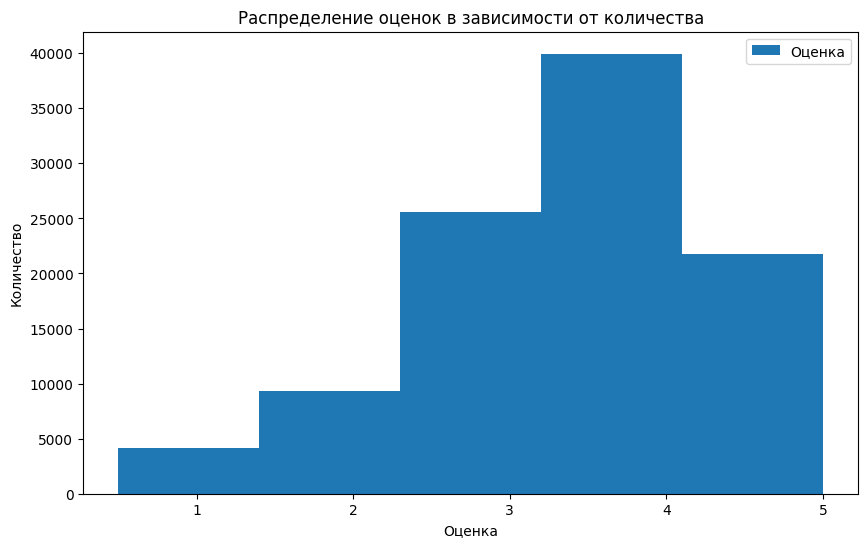

In [47]:
data = merged_df['rating']
hist, ax = plt.subplots(figsize=(10, 6))
ax.hist(data, bins=5, label='Оценка')
ax.legend()
ax.set_title("Распределение оценок в зависимости от количества")
ax.set_xlabel("Оценка")
ax.set_ylabel("Количество")
plt.show()

figures_data['hist_rating_distribution'] = hist

### Распределение по дате оценки

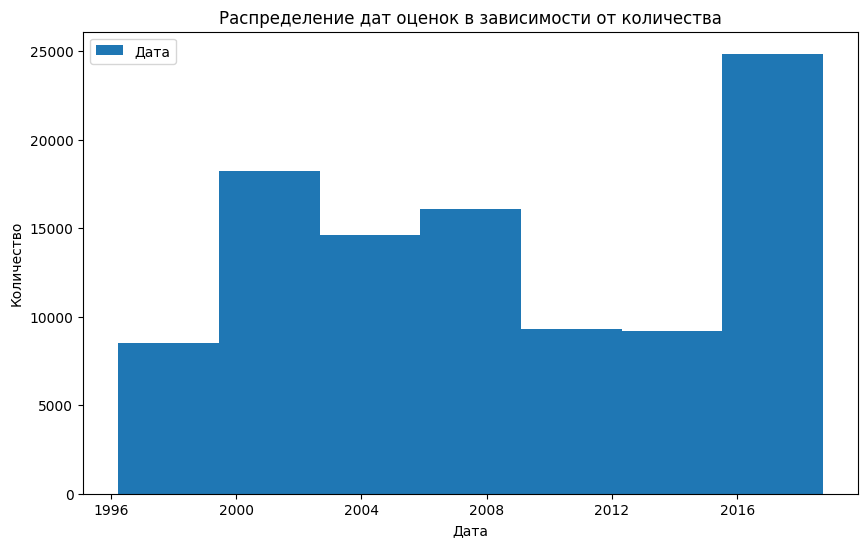

In [48]:
data = pd.to_datetime(merged_df['timestamp'], unit='s') #  Перевод в даты
hist, ax = plt.subplots(figsize=(10, 6))
ax.hist(data, bins=7, label='Дата')
ax.legend()
ax.set_title("Распределение дат оценок в зависимости от количества")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество")
plt.show()

figures_data['hist_date_distribution'] = hist

### Самые популярные фильмы

In [49]:
total_ratings = len(merged_df)

popularity = (
    merged_df.groupby('movieId') #  группируем по фильмам
    .size() #  считем вхождения каждого фильма
    .reset_index(name='count') #  даем имя
    .merge(movies_df[['movieId', 'title']], on='movieId') #  присоединяем названия
    .assign(share=lambda x: x['count'] / total_ratings) #  добавляем колонку с распредедением в долях
    .sort_values('count', ascending=False)[['title', 'count', 'share']] #  сортируем и оставляем только 'title', 'count', 'share'
)

print(popularity.head(10))

                                          title  count     share
314                         Forrest Gump (1994)    329  0.003263
277            Shawshank Redemption, The (1994)    317  0.003144
257                         Pulp Fiction (1994)    307  0.003045
510            Silence of the Lambs, The (1991)    279  0.002767
1938                         Matrix, The (1999)    278  0.002757
224   Star Wars: Episode IV - A New Hope (1977)    251  0.002489
418                        Jurassic Park (1993)    238  0.002360
97                            Braveheart (1995)    237  0.002350
507           Terminator 2: Judgment Day (1991)    224  0.002221
461                     Schindler's List (1993)    220  0.002182


### Самые лучшие фильмы по оценкам

In [50]:
min_ratings = 50  # минимум оценок для включения в топ

movie_avg_rating = (
    merged_df.groupby('movieId')['rating']
    .agg(['mean', 'count'])
    .reset_index()
    .merge(movies_df[['movieId', 'title']], on='movieId')
    .query(f'count >= {min_ratings}')
    .sort_values('mean', ascending=False)[['title', 'mean', 'count']]
)

print(movie_avg_rating.head(10))

                                                  title      mean  count
277                    Shawshank Redemption, The (1994)  4.429022    317
659                               Godfather, The (1972)  4.289062    192
2224                                  Fight Club (1999)  4.272936    218
974                               Cool Hand Luke (1967)  4.271930     57
602   Dr. Strangelove or: How I Learned to Stop Worr...  4.268041     97
686                                  Rear Window (1954)  4.261905     84
921                      Godfather: Part II, The (1974)  4.259690    129
6298                               Departed, The (2006)  4.252336    107
913                                   Goodfellas (1990)  4.250000    126
694                                   Casablanca (1942)  4.240000    100


### Матрицы корреляций

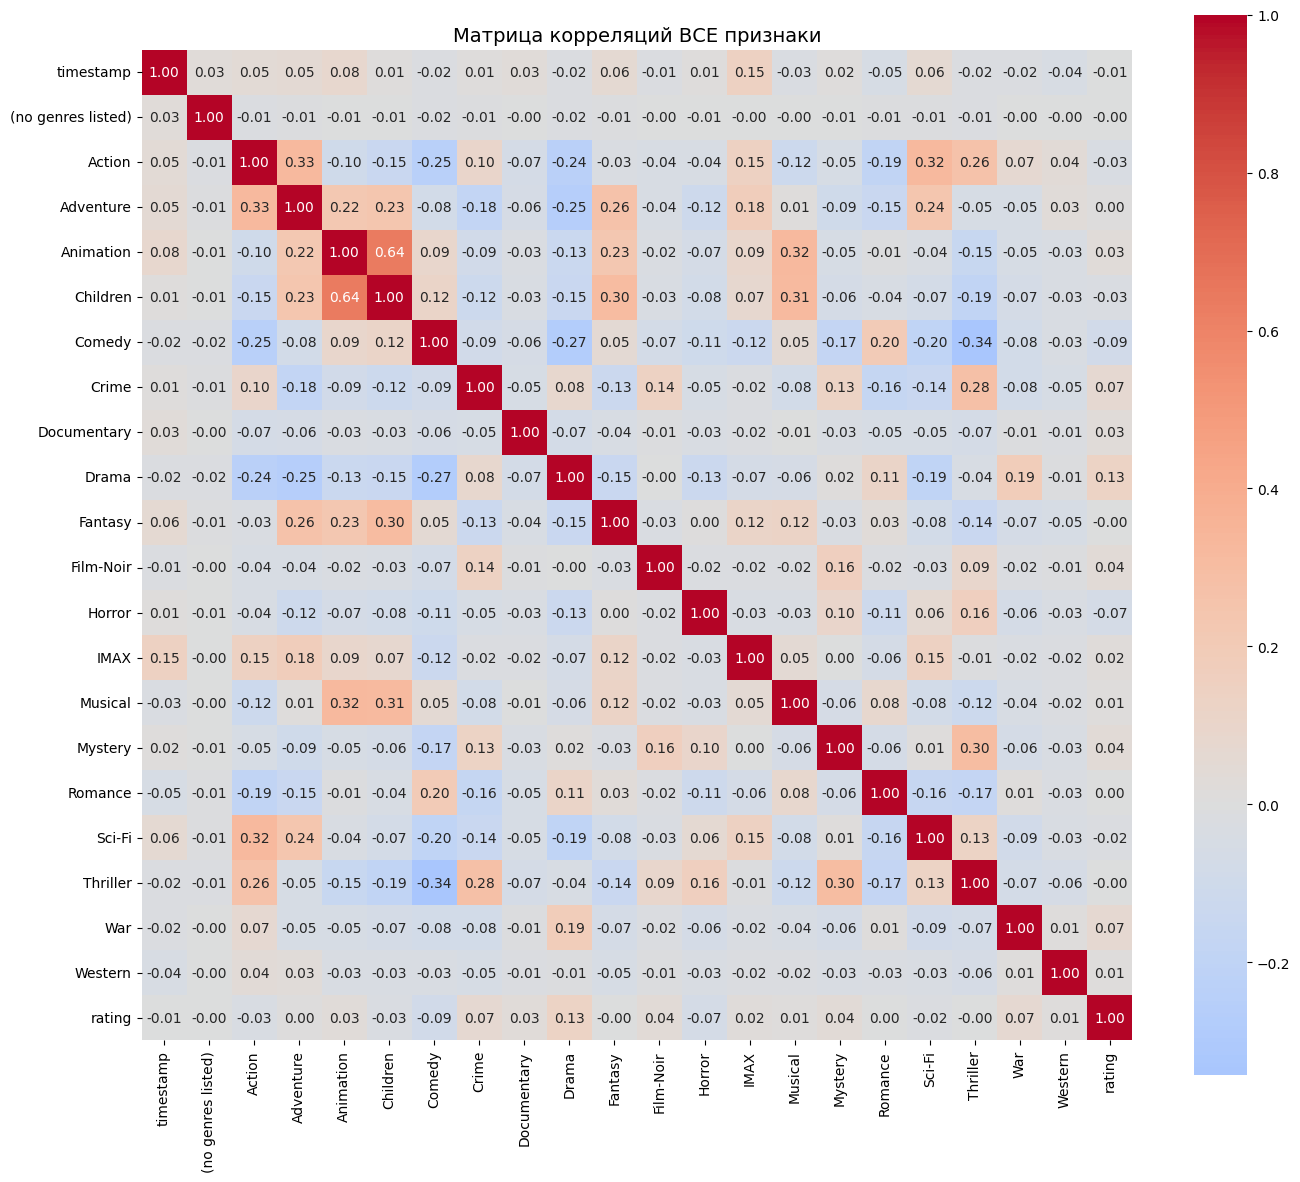

In [51]:
numeric_df = merged_df.drop(['userId', 'movieId'], axis=1).select_dtypes(include=['number'])

corr_matrix, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(numeric_df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            ax=ax)
ax.set_title('Матрица корреляций ВСЕ признаки', fontsize=14)
plt.tight_layout()
plt.show()

figures_data['corr_matrix_all_to_all'] = corr_matrix

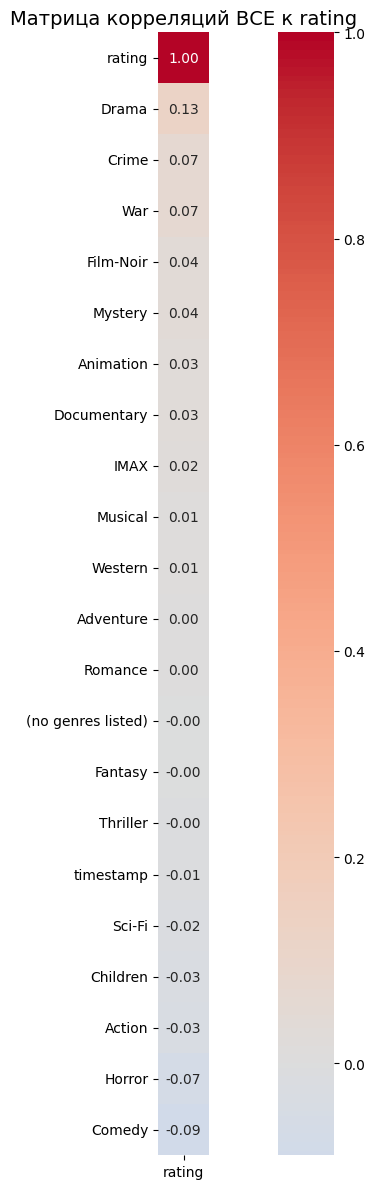

In [52]:
def make_corr_matrix_all_to_rating(df: pd.DataFrame, height = 12) -> plt.Figure:
  numeric_df = df.drop(['userId', 'movieId'], axis=1).select_dtypes(include=['number'])
  corr_matrix, ax = plt.subplots(figsize=(14, height))
  sns.heatmap(numeric_df.corr()[['rating']].sort_values(by='rating', ascending=False),
              annot=True,
              fmt='.2f',
              cmap='coolwarm',
              center=0,
              square=True,
              ax=ax)
  ax.set_title('Матрица корреляций ВСЕ к rating', fontsize=14)
  plt.tight_layout()
  plt.show()

  return corr_matrix

figures_data['corr_matrix_all_to_all'] = make_corr_matrix_all_to_rating(merged_df)

### Вывод
Датасет был изучен на корелляции, распределения и популярность

## Разделение на train/val/test выборки

In [53]:
def train_test_split_by_time(df: pd.DataFrame, split_column: str, test_size: float) -> tuple[pd.DataFrame, pd.DataFrame]:
  """
  Функция разделения по времени. Сортирует весь датасет по split_column.
  Делит записи в соотношении 1-test_size/test_size в train/test датафреймы соответственно.
  Параметры:
    df - датафрейм для деления
    split_column - колонка, по которой будет сортироваться датафрейм
    test_size - доля, которая пойдет в test
  Возвращает:
    train - выборка для обучения
    test - выборка для теста
  """
  #  Сортируем весь датасет по времени
  df_sorted = df.sort_values(split_column).reset_index(drop=True)

  #  Вычисляем индексы разделения
  train_end = int(len(df_sorted) * (1 - test_size))

  # Делим
  train = df_sorted.iloc[:train_end].copy()
  test = df_sorted.iloc[train_end:].copy()

  return train, test

genre_list = [g for g in genre_list if g!= '(no genres listed)']
merged_df = merged_df.drop(columns=['(no genres listed)'])

train, test = train_test_split_by_time(merged_df, 'timestamp', 0.2) # train/val/test в пропорции 0.7/0.1/0.2
train, val = train_test_split_by_time(train, 'timestamp', 0.125)

### Вывод
В результате были получены сырые train/val/test выборки.
ВАЖНО: для разделения было использовано разделение по времени. Это предотвращает всяческие утечки данных, обеспечивает холодный старт для новых фильмов и пользователей.

## Обогащение

Для прогнозирования по пользовательским предпочтениям необходимо выделить больше данных о нем. Важно, чтобы извлеченные данные, были строго из train. Извлечение из test и val приведет к утечке.

Будем извлекать следующие данные:
- Любимые жанры пользователя;
- Нелюбимые жанры пользователя;
- Средняя оценка фильма;
- Количество оценок фильма.

### Импорты

In [54]:
import numpy as np

### Функция обогащения для train

In [55]:
def historical_data_enrichment(df: pd.DataFrame,genres: list[str],min_ratings: int = 5,default_rating: float = 3.5,) -> pd.DataFrame:
  """
  Историческое обогащение без утечки по времени.
  Для каждой строки считаются признаки только по предыдущим записям:
    - movie_avg_rating
    - user_avg_rating
    - user_avg_<genre> для каждого жанра
  Также для фильмов с малым числом прошлых оценок используется fallback:
    - среднее по жанрам фильма на предыдущих записях
    - если жанровой истории нет, глобальное среднее по предыдущим записям
    - если вообще нет прошлых записей, default_rating
  Параметры:
    df - датафрейм для обогащения
    genres - список жанров
    min_ratings - минимальное количество оценок для высчитывания среднего
    default_rating - средний рейтинг для заполнения в случае провала более сложной логики
  Возвращает:
    out - датафрейм после обогащения
  """

  out = df.sort_values("timestamp").copy() # сортируем по времени

  # 1. Глобальное среднее ДО текущей строки
  out["_global_sum_before"] = out["rating"].cumsum() - out["rating"] #  сумма оценок до записи включительно - оценка в этой записи
  out["_global_count_before"] = np.arange(len(out)) #  количество записей до = количеству оценок

  out["_global_avg_before"] = out["_global_sum_before"] / out["_global_count_before"] #  считаем глобальное среднее до записи
  out["_global_avg_before"] = out["_global_avg_before"].fillna(default_rating) #  для начальных записей подставляем default_rating

  # 2. Средняя оценка фильма ДО текущей строки
  out["_movie_sum_before"] = out.groupby("movieId")["rating"].cumsum() - out["rating"] # сумма оценок фильма до записи
  out["_movie_count_before"] = out.groupby("movieId").cumcount() #  количество оценок фильма до записи

  out["_movie_avg_before_raw"] = out["_movie_sum_before"] / out["_movie_count_before"] #  считаем глобальное оценку фильма до записи

  # 3. Средняя оценка каждого жанра ДО текущей строки
  genre_avg_before_cols = []

  for genre in genres:
    sum_col = f"_genre_{genre}_sum_before"
    count_col = f"_genre_{genre}_count_before"
    avg_col = f"_genre_{genre}_avg_before"

    out[sum_col] = (out["rating"] * out[genre]).cumsum() - (out["rating"] * out[genre]) #  сумма рейтингов предыдущих фильмов этого жанра
    out[count_col] = out[genre].cumsum() - out[genre] #  количество предыдущих оценок фильмов этого жанра

    out[avg_col] = out[sum_col] / out[count_col]
    out[avg_col] = out[avg_col].fillna(out["_global_avg_before"])

    genre_avg_before_cols.append(avg_col)

  # 4. movie_avg_rating с fallback по жанрам
  out["movie_avg_rating"] = np.where(
    out["_movie_count_before"] >= min_ratings,
    out["_movie_avg_before_raw"],
    np.nan
  ) # если количество больше или равно min_ratings, то добавляем, иначе nan

  def movie_genre_fallback(row):
    """
    Функция заполненния пропусков в средней оценке фильма
    Параметры:
      row - запись
    Возвращает:
      оценку
    """
    movie_genres = [g for g in genres if row[g] == 1]

    #  если нет жанров, то возвращаем глобальную оценку до
    if len(movie_genres) == 0:
        return row["_global_avg_before"]

    # собирем средние оценки жанров, которые есть у фильма
    values = []
    for g in movie_genres:
        value = row[f"_genre_{g}_avg_before"]
        if not pd.isna(value):
            values.append(value)

    # Если оценки нашлись, то возвращаем среднее по жанрам
    if len(values) > 0:
        return float(np.mean(values))

    # Если все же не нашлось, то глобальное среднее
    return row["_global_avg_before"]

  missing_movie_avg = out["movie_avg_rating"].isna() #  собираем nan-оценки фильмов

  out.loc[missing_movie_avg, "movie_avg_rating"] = (out.loc[missing_movie_avg].apply(movie_genre_fallback, axis=1)) #  заполняем пропуски по логике функции

  out["movie_avg_rating"] = out["movie_avg_rating"].fillna(out["_global_avg_before"]) #  заполняем пропуски глобальной средней оценкой на всякий случай

  # 5. Средняя оценка пользователя ДО текущей строки
  out["_user_sum_before"] = out.groupby("userId")["rating"].cumsum() - out["rating"]
  out["_user_count_before"] = out.groupby("userId").cumcount()

  out["user_avg_rating"] = out["_user_sum_before"] / out["_user_count_before"]

  out["user_avg_rating"] = out["user_avg_rating"].fillna(out["_global_avg_before"]) #  для первых записей заполняем глобальной средней оценкой

  # 6. Средняя оценка пользователя по каждому жанру ДО текущей строки
  for genre in genres:
    user_genre_sum_col = f"_user_{genre}_sum_before"
    user_genre_count_col = f"_user_{genre}_count_before"
    user_genre_avg_col = f"user_avg_{genre}"

    rating_for_genre = out["rating"] * out[genre] #  оставляем только оценки фильмов с этим жанром

    # каждому пользователю проставляем сумму оценок этого жанра по его предыдущим
    out[user_genre_sum_col] = rating_for_genre.groupby(out["userId"]).cumsum() - rating_for_genre
    out[user_genre_count_col] = out[genre].groupby(out["userId"]).cumsum() - out[genre]

    out[user_genre_avg_col] = out[user_genre_sum_col] / out[user_genre_count_col]

    # если пользователь раньше не оценивал этот жанр, подставляем историческое среднее жанра
    out[user_genre_avg_col] = out[user_genre_avg_col].fillna(out[f"_genre_{genre}_avg_before"])

    # если и жанровой истории ещё нет, подставляем глобальное прошлое среднее.
    out[user_genre_avg_col] = out[user_genre_avg_col].fillna(out["_global_avg_before"])

  # 7. Удаляем технические колонки
  technical_cols = [col for col in out.columns if col.startswith("_")] #  если строка начинается с _, то записываем
  out = out.drop(columns=technical_cols) #  удаляем записанное

  return out

### Функция обогащения для val и test

In [56]:
def add_offline_features_from_train(
    target_df: pd.DataFrame,
    train_df: pd.DataFrame,
    genres: list[str],
    min_ratings: int = 5,
    default_rating: float = 3.5,
) -> pd.DataFrame:
    """
    Считает новые признаки по train_df.
    Параметры: 
        target_df - датафрейм для обогащения
        train_df - датафрейм, по которому обогащают
        genres - список жанров
        min_ratings - минимальное количество для вы
        default_rating - средний рейтинг для заполнения в случае провала более сложной логики
    Возвращает:
        out - датафрейм после обогащения
    """

    out = target_df.copy()

    global_mean = train_df["rating"].mean()
    if pd.isna(global_mean):
        global_mean = default_rating

    # 1. movie_avg_rating по train
    movie_stats = train_df.groupby("movieId")["rating"].agg(movie_avg_train="mean", movie_count_train="count")

    out = out.merge(movie_stats,on="movieId",how="left")

    # 2. Средние рейтинги жанров по train
    genre_means = {}

    for genre in genres:
        mask = train_df[genre] == 1

        if mask.sum() > 0:
            genre_means[genre] = train_df.loc[mask, "rating"].mean()
        else:
            genre_means[genre] = global_mean

    # 3. fallback для фильмов с малым числом оценок или неизвестных фильмов
    genre_matrix = out[genres].to_numpy()

    genre_values = np.array([genre_means[g] for g in genres])
    genre_sum = genre_matrix @ genre_values
    genre_count = genre_matrix.sum(axis=1)

    movie_genre_fallback = np.where(
        genre_count > 0,
        genre_sum / genre_count,
        global_mean
    )

    out["movie_avg_rating"] = np.where(
        out["movie_count_train"] >= min_ratings,
        out["movie_avg_train"],
        movie_genre_fallback,
    )

    out["movie_avg_rating"] = pd.Series(out["movie_avg_rating"]).fillna(global_mean).values

    out = out.drop(columns=["movie_avg_train", "movie_count_train"])

    # 4. user_avg_rating по train
    user_avg = train_df.groupby("userId")["rating"].mean()

    out["user_avg_rating"] = out["userId"].map(user_avg)
    out["user_avg_rating"] = out["user_avg_rating"].fillna(global_mean)

    # 5. user_avg_<genre> по train
    for genre in genres:
        user_genre_avg = (
            train_df[train_df[genre] == 1]
            .groupby("userId")["rating"]
            .mean()
        )

        out[f"user_avg_{genre}"] = out["userId"].map(user_genre_avg)

        # Если пользователь не оценивал этот жанр в train, берём среднее жанра по train.
        out[f"user_avg_{genre}"] = out[f"user_avg_{genre}"].fillna(genre_means[genre])

        # Если и жанра нет, глобальное среднее.
        out[f"user_avg_{genre}"] = out[f"user_avg_{genre}"].fillna(global_mean)

    return out.copy()

### Функция с пайплайном по обогащению

In [57]:
def offline_historical_enrichment(train_df: pd.DataFrame, val_df: pd.DataFrame,test_df: pd.DataFrame, genres: list[str],
    min_ratings: int = 5,default_rating: float = 3.5,):
    """
    Функция с пайплайном по обогащению. Обогащает историчестки train -> offline val -> исторически train+val -> offline test
    """

    train_enriched = historical_data_enrichment(
        df=train_df,
        genres=genres,
        min_ratings=min_ratings,
        default_rating=default_rating,
    )

    val_enriched = add_offline_features_from_train(
        target_df=val_df,
        train_df=train_df,
        genres=genres,
        min_ratings=min_ratings,
        default_rating=default_rating,
    )

    known_history_for_test = pd.concat(
        [train_df, val_df],
        axis=0,
        ignore_index=True,
    )

    test_enriched = add_offline_features_from_train(
        target_df=test_df,
        train_df=known_history_for_test,
        genres=genres,
        min_ratings=min_ratings,
        default_rating=default_rating,
    )

    return train_enriched, val_enriched, test_enriched

In [58]:
train, val, test = offline_historical_enrichment(train, val, test, genre_list)

C:\Users\TUF A15\AppData\Local\Temp\ipykernel_15324\2916853883.py:111: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[user_genre_count_col] = out[genre].groupby(out["userId"]).cumsum() - out[genre]
C:\Users\TUF A15\AppData\Local\Temp\ipykernel_15324\2916853883.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[user_genre_avg_col] = out[user_genre_sum_col] / out[user_genre_count_col]
C:\Users\TUF A15\AppData\Local\Temp\ipykernel_15324\2916853883.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usuall

### Проверка качества обогащенного датасета

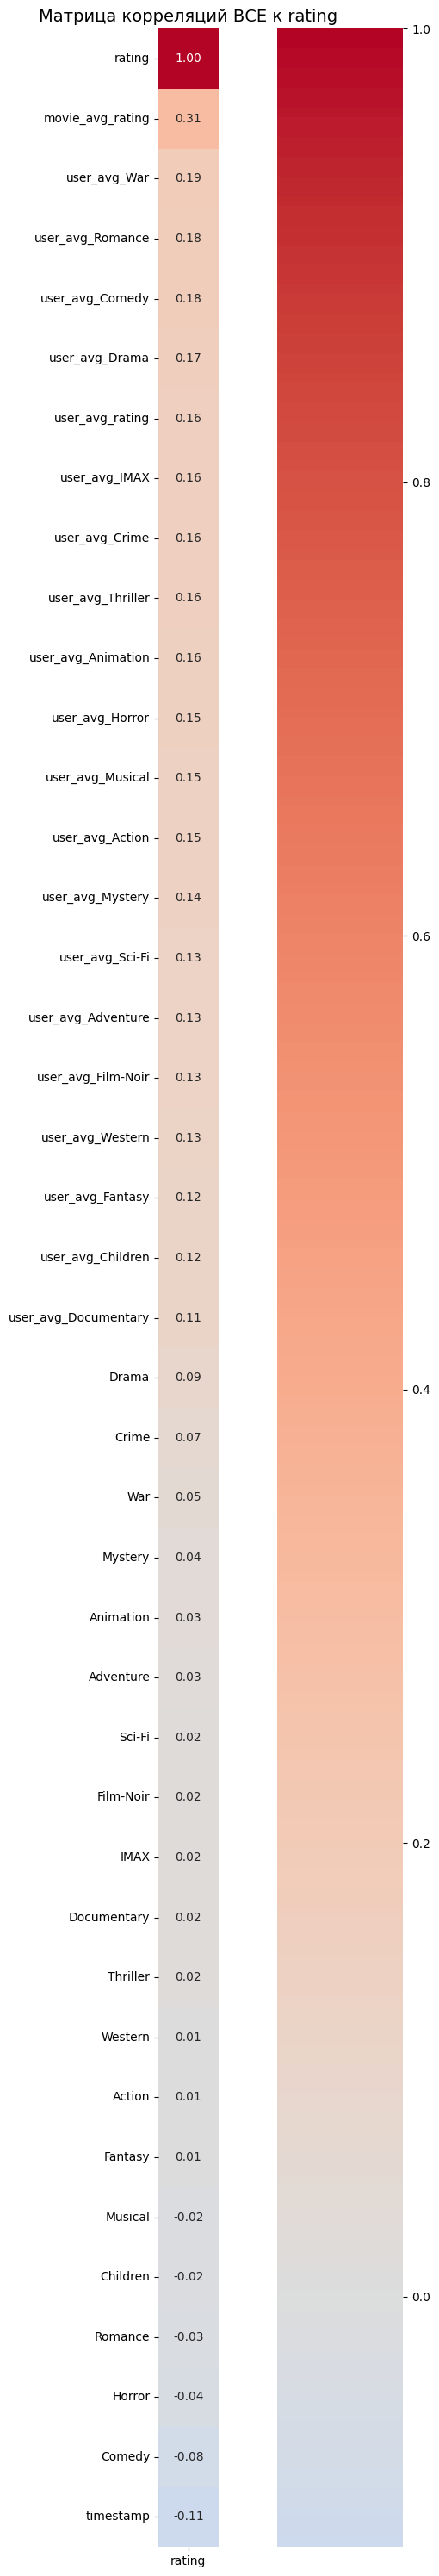

In [59]:
figures_data['corr_matrix_all_to_rating_enriched'] = make_corr_matrix_all_to_rating(test, 30)

In [60]:
check_data_quality(test)

--------------------структура--------------------
   userId  movieId   timestamp  Action  Adventure  Animation  Children  \
0     495    72998  1458635171       1          1          0         0   

   Comedy  Crime  Documentary  ...  user_avg_Film-Noir  user_avg_Horror  \
0       0      0            0  ...            3.941982             4.25   

   user_avg_IMAX  user_avg_Musical  user_avg_Mystery  user_avg_Romance  \
0          4.875          3.597957               4.5               4.5   

   user_avg_Sci-Fi  user_avg_Thriller  user_avg_War  user_avg_Western  
0         4.642857              4.125           4.0               5.0  

[1 rows x 44 columns]
--------------------размерность--------------------
(20168, 44)
--------------------информация по столбцам--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20168 entries, 0 to 20167
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  ----

In [61]:
final_datasets['train'] = train
final_datasets['val'] = val
final_datasets['test'] = test

### Вывод
Как можно заметить из матрицы корелляций, в результате обогащения был получен ряд сильных признаков с высокой корелляцией, которые сильно помогут в дальнейшем обучении. Данные качественные, без мусора

## Артефакты

In [ ]:
artifacts_directory_path = os.path.join('..','artifacts','experiments','exp01') #  создание папки для артефактов этого ноутбука
os.makedirs(artifacts_directory_path, exist_ok=True)

### Сохранение и удаление датасетов

Для дальнейшего понадобятся:
- train/val/test датасеты;
- сырой объединенный датасет.

Нужно удалить:
 - разъединенные файлы, извлеченные из архива.

In [63]:
#  Удаление файлов из архива
for file in files_to_extract:
  path = os.path.join(directory_to_load_path, file)
  os.remove(path)

for name, dataset in final_datasets.items():
  path = os.path.join(directory_to_load_path, name) + '.csv'
  dataset.to_csv(path, sep=',', index=False)

### Сохранение графиков

In [64]:
figures_directory_path = os.path.join(artifacts_directory_path, 'figures') #  создание папки для графиков
os.makedirs(figures_directory_path, exist_ok=True)

for name, figure in figures_data.items():
  path = os.path.join(figures_directory_path, name) + '.png'
  figure.savefig(path)

## Заключение

Результатом данного ноутбука является полный пайплайн работы с датасетом:
- Установка и распаковка архива;
- Исследование качества датасета;
- Сборка итогового датасета в одном файле;
- EDA;
- Разбиение на train/val/test выборки;
- Обогащение.

В дальшейшем код из этого ноутбука будет использован для обработки более тяжелого датасета для итоговой модели